# Instrument simulator

Generates "realistic" data products based on input source spectrum, instrument throughput parameters, dispersion, lens vignetting, and detector response.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
from spec_wcs import LongSlitWCS
from simulator import ThroughputCurve, DetectorModel, SpectrographModel, InstrumentSimulator

In [2]:
spec = np.loadtxt("../data/SN_ref_spectra/SNIa_max_z0p05.txt")
wave = spec[:, 0]
flux = spec[:, 1]
flux /= np.max(flux)

In [3]:
fiber_wav, fiber_att = np.loadtxt("../data/csv files/fiber_attenuation.csv", delimiter=",").T
fiber_tx = 10 ** (-(fiber_att * (10. / 1000.)) / 10)
fiber = ThroughputCurve(fiber_wav*10, fiber_tx, name="fiber")

In [4]:
lenses = ThroughputCurve(wavelength=np.array([3000, 10000]), throughput=np.array([0.98, 0.98]), name="lenses")

grating = ThroughputCurve.from_csv("../data/csv files/master 1294 unpolarized.csv", name="grating")

qe = ThroughputCurve.from_csv("../data/csv files/Kepler_qe.csv", name="detector QE")

detector = DetectorModel(
    nx=2048,
    ny=2048,
    gain_e_per_adu=0.5,
    read_noise_e=1.6,
    dark_current_e_per_s=0.4,
    bias_adu=200.0,
    full_well_e=90000.0,
)

spectrograph = SpectrographModel(
    central_wavelength=6000.0,       # Angstrom
    dispersion=3.4349,               # Angstrom / pixel
    x_center=(detector.nx - 1) / 2,
    trace_y=(detector.ny - 1) / 2,
    spectral_sigma_px=2.04,
    spatial_sigma_px=2.25,
    kernel_radius_sigma=4.0,
)

sim = InstrumentSimulator(
    spectrograph=spectrograph,
    detector=detector,
    throughputs=[fiber, lenses, grating, qe],
)

In [5]:
def camera_lens_vignetting(yy, xx):
    x0 = detector.nx / 2
    y0 = detector.ny / 2

    rx = (xx - x0) / x0
    ry = (yy - y0) / y0
    r2 = rx**2 + ry**2

    return 1.0 - 0.1 * r2

exptime = 600.
image_adu = sim.simulate(
    wavelength=wave,
    flux_density=flux,
    exposure_s=exptime,
    exposure_scale=100.0,
    vignetting=camera_lens_vignetting,
    add_noise=True,
    seed=123,
)

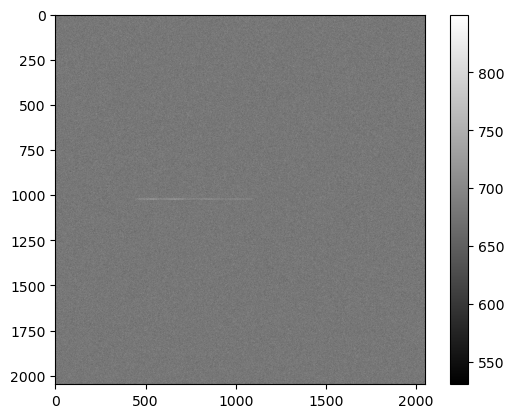

In [6]:
plt.imshow(image_adu, cmap="binary_r")
# plt.ylim(1000, 1048)
plt.colorbar()
plt.show()

In [7]:
reference_ra_deg = 12.
reference_dec_deg = 30.
slit_position_angle_deg = 0.

wcs = LongSlitWCS.from_instrument(
    nx=2048,
    ny=2048,
    ra_deg=reference_ra_deg,
    dec_deg=reference_dec_deg,
    position_angle_deg=slit_position_angle_deg,
    reference_pixel=(1023.5, 1023.5),
)

In [8]:
hdu = fits.PrimaryHDU(image_adu)
hdu.header["LOCATION"] = "Mt Laguna Observatory", "Observatory/location"
hdu.header["TELESCOP"] = "Claud 1.25-m Telescope", "Telescope name"
hdu.header["INSTRUME"] = "Fiber-fed spectrograph", "Instrument name"
hdu.header["ORIGIN"] = "SDSU", ""
hdu.header["CAMERA"] = "FLI Kepler KL400", "Camera model"
hdu.header["DETECTOR"] = "GSENSE400BSI", "Detector model"
hdu.header["PIXSIZE"] = 11., "[micron] Pixel size"
hdu.header["CCD-TEMP"] = -20., "[degC] Sensor temperature during exposure"
hdu.header["IMAGETYP"] = "Simulated", "Image type (light, dark, flat, wavecal, etc.)"
hdu.header["OBJECT"] = "SNIa_test", "Target name"
hdu.header["STAGEX"] = 0., "Guider/fiber stage X position"
hdu.header["STAGEY"] = 0., "Guider/fiber stage Y position"
hdu.header["EXPTIME"] = exptime, "[s] Exposure time"
hdu.header["LAMPSTAT"] = False, "Calibration arc lamp state (T=on, F=off)"
hdu.header.update(wcs.to_header())
hdu.header["TIMESYS"] = "UTC", "Time system in use"
hdu.header["DATE"] = Time.now().utc.isot, "HDU creation time"

In [9]:
hdu.writeto("simulated_SNIa_spectrum.fits", overwrite=True)